# 🔭 Celestial Object Detection — Complete Training Notebook

## What this notebook does

| Section | Task | Time |
|---|---|---|
| A | Setup — mount Drive, install, imports | 3 min |
| B | Download SDSS images (galaxy/star/quasar) | ~45 min |
| C | Train ResNet50 classifier | ~40 min |
| D | Evaluate — accuracy, confusion matrix, per-class results | 5 min |
| E | Build 3-stage detection pipeline | 2 min |
| F | Test pipeline on your telescope image | 5 min |
| G | Save all model files to Drive | 2 min |

**Total: ~1.5 hours**

---
## Files saved to Drive after this runs
```
MyDrive/CelestialV2/
├── resnet50_classifier.pt   ← add to local model/ folder
├── classes.txt              ← add to local model/ folder
├── yolo_best.pt             ← your existing YOLO model (copied here)
└── results/
    ├── training_curves.png
    ├── confusion_matrix.png
    ├── classifier_samples.png
    └── pipeline_result.png
```

---
⚠️ **Set runtime to GPU before running: Runtime → Change runtime type → T4 GPU**

---
# A — Setup

In [ ]:
# A1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# ── All paths live here — change nothing else ──────────────────
BASE_DIR    = '/content/drive/MyDrive/CelestialV2'
IMG_DIR     = os.path.join(BASE_DIR, 'sdss_images')      # downloaded SDSS images
RESULTS_DIR = os.path.join(BASE_DIR, 'results')           # charts and outputs
CLASSIFIER  = os.path.join(BASE_DIR, 'resnet50_classifier.pt')
CLASSES_TXT = os.path.join(BASE_DIR, 'classes.txt')

# Your existing YOLOv8 model from previous training
# ── CHANGE THIS if your model is in a different location ──
YOLO_SRC    = '/content/drive/MyDrive/best_model.pt'
YOLO_DST    = os.path.join(BASE_DIR, 'yolo_best.pt')

for d in [BASE_DIR, IMG_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
for cls in ['GALAXY', 'STAR', 'QSO']:
    os.makedirs(os.path.join(IMG_DIR, cls), exist_ok=True)

# Copy YOLO model to new project folder
import shutil
if os.path.exists(YOLO_SRC) and not os.path.exists(YOLO_DST):
    shutil.copy2(YOLO_SRC, YOLO_DST)
    print(f'YOLO model copied to: {YOLO_DST}')
elif os.path.exists(YOLO_DST):
    print(f'YOLO model already at: {YOLO_DST}')
else:
    print(f'WARNING: YOLO model not found at {YOLO_SRC}')
    print('Pipeline will run without YOLO — photutils + classifier only')

print('Directories ready.')

Mounted at /content/drive
YOLO model copied to: /content/drive/MyDrive/CelestialV2/yolo_best.pt
Directories ready.


In [ ]:
# A2 — Install packages
!pip install ultralytics photutils astropy --quiet

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 90.1 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# A3 — All imports
import glob, random, json, time
import numpy as np
import pandas as pd
import requests
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from ultralytics import YOLO

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['GALAXY', 'STAR', 'QSO']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
random.seed(42)
torch.manual_seed(42)
print(f'Device: {DEVICE}')
print('All imports OK.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
All imports OK.


---
# B — Download SDSS Images

Downloads 3,000 images per class (9,000 total) from SDSS SkyServer.
If some already downloaded it skips them — safe to re-run.

**Expected time: 30–50 minutes**

In [ ]:
# B1 — Load SDSS catalog
# Uses the standard Kaggle SDSS stellar classification dataset

CSV_PATH = os.path.join(BASE_DIR, 'star_classification.csv')

# Corrected SQL query (removed redshift as it causes a server error)
SQL = '''
SELECT TOP 100000
    p.objID, p.ra, p.dec,
    p.u, p.g, p.r, p.i, p.z,
    s.class
FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestobjid = p.objid
WHERE s.class IN ('GALAXY','STAR','QSO')
  AND p.r BETWEEN 13 AND 20
'''.replace('\n',' ').strip()

# Check if CSV exists and is valid. If not, re-download.
# The previous execution output shows an error was written to the CSV.
if os.path.exists(CSV_PATH):
    try:
        # Read only a few lines to check for headers, avoid full load of large corrupted file
        with open(CSV_PATH, 'r') as f:
            first_line = f.readline()
        # Check if the first line looks like a typical CSV header or an error message
        # A valid header would contain 'objid', 'ra', 'dec', 'class', etc.
        # An error message might contain 'errorcode' or 'errormessage'.
        if 'errorcode' in first_line.lower() or 'errormessage' in first_line.lower():
            print(f'Corrupted CSV found at {CSV_PATH}. Deleting and re-downloading.')
            os.remove(CSV_PATH)
        else:
            # Try to load fully to be sure, this handles cases where error is not in first line
            temp_df = pd.read_csv(CSV_PATH, comment='#')
            if 'objid' not in temp_df.columns or 'class' not in temp_df.columns:
                print(f'Corrupted CSV found at {CSV_PATH}. Deleting and re-downloading.')
                os.remove(CSV_PATH)
            del temp_df # Delete temp_df to free memory
    except Exception as e:
        print(f'Error reading existing CSV: {e}. Deleting and re-downloading.')
        os.remove(CSV_PATH)

if not os.path.exists(CSV_PATH):
    print('Fetching catalog from SDSS SkyServer...')
    url  = (f'https://skyserver.sdss.org/dr17/SkyServerWS/SearchTools/SqlSearch'
            f'?cmd={requests.utils.quote(SQL)}&format=csv')
    resp = requests.get(url, timeout=120)
    with open(CSV_PATH, 'w') as f:
        f.write(resp.text)
    print(f'Saved: {CSV_PATH}')
else:
    print(f'CSV already exists and is valid: {CSV_PATH}')

df = pd.read_csv(CSV_PATH, comment='#')
# Normalize columns
df.columns = [c.lower().strip() for c in df.columns]
if 'alpha' in df.columns: df = df.rename(columns={'alpha':'ra','delta':'dec'})
df['class'] = df['class'].str.upper().str.strip()
df = df[df['class'].isin(['GALAXY','STAR','QSO'])].dropna(subset=['ra','dec'])

print(f'Catalog loaded: {len(df)} objects')
print(df['class'].value_counts())

Corrupted CSV found at /content/drive/MyDrive/CelestialV2/star_classification.csv. Deleting and re-downloading.
Fetching catalog from SDSS SkyServer...
Saved: /content/drive/MyDrive/CelestialV2/star_classification.csv
Catalog loaded: 100000 objects
class
GALAXY    59846
STAR      32987
QSO        7167
Name: count, dtype: int64


In [ ]:
# B2 — Download images from SDSS cutout service
# 3000 per class = 9000 total
# Already downloaded images are skipped automatically

N_PER_CLASS = 3000

frames = []
for cls in CLASS_NAMES:
    sub = df[df['class'] == cls]
    n   = min(N_PER_CLASS, len(sub))
    frames.append(sub.sample(n, random_state=42))
    print(f'  {cls}: {len(sub)} available → sampling {n}')
df_sample = pd.concat(frames).reset_index(drop=True)

def download_image(ra, dec, cls, stem):
    dst = os.path.join(IMG_DIR, cls, f'{stem}.jpg')
    if os.path.exists(dst) and os.path.getsize(dst) > 500:
        return True
    url = (f'https://skyserver.sdss.org/dr17/SkyServerWS/ImgCutout/getjpeg'
           f'?ra={ra}&dec={dec}&scale=0.4&width=64&height=64')
    try:
        r = requests.get(url, timeout=12)
        if r.status_code == 200 and len(r.content) > 500:
            with open(dst, 'wb') as f:
                f.write(r.content)
            return True
    except Exception:
        pass
    return False

ok = fail = 0
for i, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Downloading SDSS'):
    if download_image(row['ra'], row['dec'], row['class'], f'sdss_{i}'):
        ok += 1
    else:
        fail += 1
    if i % 200 == 0 and i > 0:
        time.sleep(1)   # be polite to SDSS server

print(f'\nDownload complete: {ok} OK, {fail} failed')
print('\nImage counts per class:')
total = 0
for cls in CLASS_NAMES:
    n = len(glob.glob(os.path.join(IMG_DIR, cls, '*.jpg')))
    total += n
    bar = '█' * (n // 100)
    print(f'  {cls:<8s}  {n:5d}  {bar}')
print(f'  TOTAL    {total}')

  GALAXY: 59846 available → sampling 3000
  STAR: 32987 available → sampling 3000
  QSO: 7167 available → sampling 3000



Download complete: 9000 OK, 0 failed

Image counts per class:
  GALAXY     3000  ██████████████████████████████
  STAR       3000  ██████████████████████████████
  QSO        3000  ██████████████████████████████
  TOTAL    9000


---
# C — Train ResNet50 Classifier

Trains ResNet50 on SDSS images.
Includes class weighting to handle imbalance.

**Expected accuracy: 90–96%**
**Expected time: 30–45 minutes on T4**

In [ ]:
# C1 — Build dataset

all_files  = []
all_labels = []
for cls in CLASS_NAMES:
    imgs = glob.glob(os.path.join(IMG_DIR, cls, '*.jpg'))
    good = []
    for p in imgs:
        try:
            with Image.open(p) as im:
                im.verify()
            good.append(p)
        except Exception:
            pass
    all_files.extend(good)
    all_labels.extend([CLASS_TO_IDX[cls]] * len(good))
    print(f'  {cls:<8s}  {len(good)} valid images')

print(f'\nTotal: {len(all_files)} images')
assert len(all_files) > 100, 'Not enough images! Check download step.'

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels, test_size=0.15,
    stratify=all_labels, random_state=42
)
print(f'Train: {len(train_files)}  Val: {len(val_files)}')

  GALAXY    3000 valid images
  STAR      3000 valid images
  QSO       3000 valid images

Total: 9000 images
Train: 7650  Val: 1350


In [ ]:
# C2 — Dataset class + transforms

class SDSSDataset(Dataset):
    def __init__(self, files, labels, transform):
        self.files, self.labels, self.transform = files, labels, transform

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (64, 64), 0)
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
infer_tf = val_tf   # same as val — no augmentation

# Class weights — fix imbalance
counts       = Counter(train_labels)
n_train      = len(train_labels)
class_weights = torch.tensor(
    [n_train / (len(CLASS_NAMES) * counts[i]) for i in range(len(CLASS_NAMES))],
    dtype=torch.float
).to(DEVICE)
print(f'Class weights: {[f"{w:.3f}" for w in class_weights.tolist()]}')

BATCH = 64
train_dl = DataLoader(SDSSDataset(train_files, train_labels, train_tf),
                      batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(SDSSDataset(val_files,   val_labels,   val_tf),
                      batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_dl)}  Val batches: {len(val_dl)}')

Class weights: ['1.000', '1.000', '1.000']
Train batches: 120  Val batches: 22


In [ ]:
# C3 — Build ResNet50 model

EPOCHS    = 40
PATIENCE  = 35

clf = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze only early layers
for name, p in clf.named_parameters():
    p.requires_grad = 'layer1' not in name and 'layer2' not in name

# Better classification head
clf.fc = nn.Sequential(
    nn.Linear(clf.fc.in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(CLASS_NAMES))
)
clf = clf.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, clf.parameters()),
    lr=0.0003, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.001,
    total_steps=EPOCHS * len(train_dl) # Explicitly set total_steps
)

trainable = sum(p.numel() for p in clf.parameters() if p.requires_grad)
print(f'Model: ResNet50  |  Trainable params: {trainable:,}  |  Device: {DEVICE}')

Model: ResNet50  |  Trainable params: 23,124,291  |  Device: cuda


In [ ]:
# C4 — Training loop (40 epochs, early stopping patience=10)

# EPOCHS    = 40  # Moved to C3
# PATIENCE  = 35  # Moved to C3
best_acc  = 0.0
no_improve = 0
history   = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[]}

for epoch in range(1, EPOCHS+1):
    # ── Train ──────────────────────────────────────────────────
    clf.train()
    tl = tc = tt = 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = clf(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == labels).sum().item()
        tt += imgs.size(0)

    # ── Validate ───────────────────────────────────────────────
    clf.eval()
    vl = vc = vt = 0
    cc = [0]*3;  ct = [0]*3   # per-class correct / total
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = clf(imgs)
            loss  = criterion(out, labels)
            vl   += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            vc   += (preds == labels).sum().item()
            vt   += imgs.size(0)
            for i in range(3):
                mask  = labels == i
                cc[i] += (preds[mask] == i).sum().item()
                ct[i] += mask.sum().item()

    t_acc = tc / tt;  v_acc = vc / vt
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_loss'].append(tl / tt)
    history['val_loss'].append(vl / vt)

    per = ' | '.join(f'{CLASS_NAMES[i][:3]}:{cc[i]/max(ct[i],1):.2f}' for i in range(3))

    if v_acc > best_acc:
        best_acc   = v_acc
        no_improve = 0
        torch.save({'model_state_dict': clf.state_dict(),
                    'class_names': CLASS_NAMES,
                    'val_acc': v_acc, 'epoch': epoch}, CLASSIFIER)
        tag = ' ★'
    else:
        no_improve += 1
        tag = ''

    print(f'Ep {epoch:3d}/{EPOCHS}  '
          f'train={t_acc:.4f}  val={v_acc:.4f}  [{per}]{tag}')

    if no_improve >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

print(f'\n✅ Best val accuracy: {best_acc*100:.2f}%')
print(f'Saved: {CLASSIFIER}')

Ep   1/40  train=0.8609  val=0.8252  [GAL:0.96 | STA:0.63 | QSO:0.89] ★
Ep   2/40  train=0.8586  val=0.8578  [GAL:0.95 | STA:0.86 | QSO:0.77] ★
Ep   3/40  train=0.8635  val=0.8778  [GAL:0.94 | STA:0.84 | QSO:0.85] ★
Ep   4/40  train=0.8682  val=0.8607  [GAL:0.93 | STA:0.84 | QSO:0.81]
Ep   5/40  train=0.8692  val=0.8696  [GAL:0.96 | STA:0.80 | QSO:0.85]
Ep   6/40  train=0.8688  val=0.8385  [GAL:0.92 | STA:0.91 | QSO:0.69]
Ep   7/40  train=0.8745  val=0.8104  [GAL:0.88 | STA:0.90 | QSO:0.65]
Ep   8/40  train=0.8809  val=0.8378  [GAL:0.92 | STA:0.93 | QSO:0.67]
Ep   9/40  train=0.8793  val=0.8363  [GAL:0.95 | STA:0.78 | QSO:0.78]
Ep  10/40  train=0.8800  val=0.8726  [GAL:0.96 | STA:0.86 | QSO:0.80]
Ep  11/40  train=0.8842  val=0.8519  [GAL:0.97 | STA:0.86 | QSO:0.72]
Ep  12/40  train=0.8846  val=0.8578  [GAL:0.96 | STA:0.88 | QSO:0.73]
Ep  13/40  train=0.8876  val=0.8622  [GAL:0.98 | STA:0.90 | QSO:0.71]
Ep  14/40  train=0.8859  val=0.8111  [GAL:0.93 | STA:0.95 | QSO:0.55]
Ep  15/40  tra

ValueError: Tried to step 4801 times. The specified number of total steps is 4800

In [ ]:
# Save the current state of the classifier
current_model_path = os.path.join(BASE_DIR, 'resnet50_classifier_current.pt')
torch.save({
    'model_state_dict': clf.state_dict(),
    'class_names': CLASS_NAMES
}, current_model_path)
print(f'Current model saved to: {current_model_path}')

Current model saved to: /content/drive/MyDrive/CelestialV2/resnet50_classifier_current.pt


---
# D — Evaluate Classifier

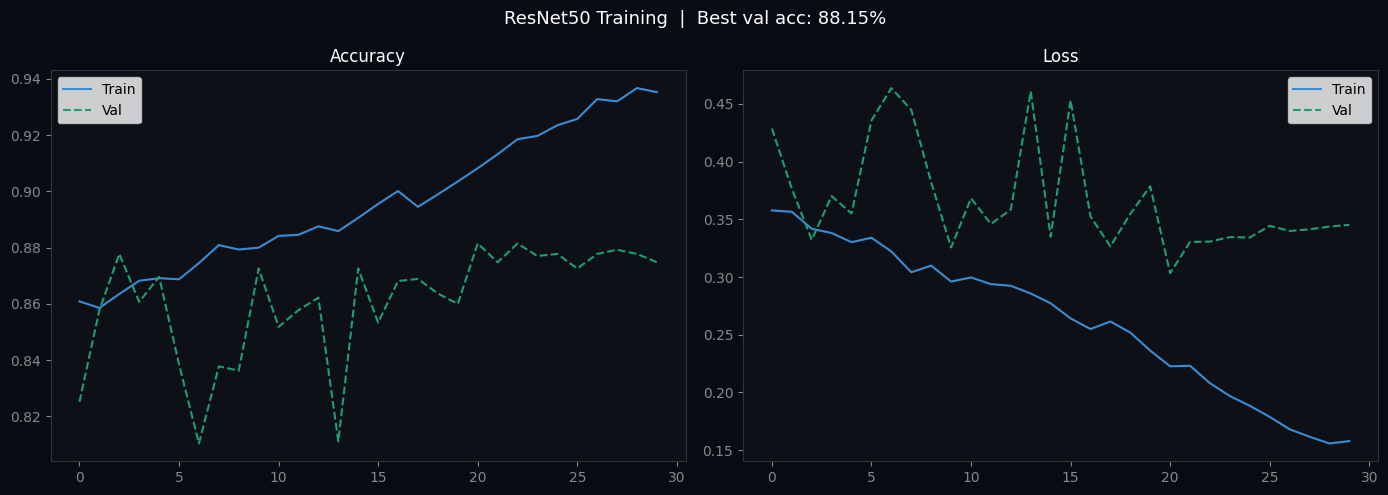

Saved: /content/drive/MyDrive/CelestialV2/results/training_curves.png


In [ ]:
# D1 — Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#080b14')
for ax, metric, title in zip(axes, ['acc','loss'], ['Accuracy','Loss']):
    ax.plot(history[f'train_{metric}'], color='#3B8BD4', linewidth=1.5, label='Train')
    ax.plot(history[f'val_{metric}'],   color='#1D9E75', linewidth=1.5, label='Val', linestyle='--')
    ax.set_title(title, color='white', fontsize=12)
    ax.set_facecolor('#0d1117')
    ax.legend()
    ax.tick_params(colors='#888')
    for s in ax.spines.values(): s.set_edgecolor('#333')
plt.suptitle(f'ResNet50 Training  |  Best val acc: {best_acc*100:.2f}%',
             color='white', fontsize=13)
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(p, dpi=130, bbox_inches='tight', facecolor='#080b14')
plt.show()
print('Saved:', p)

Loaded best model (epoch 21, val_acc=88.15%)

=== Classification Report ===
              precision    recall  f1-score   support

      GALAXY       0.94      0.98      0.96       450
        STAR       0.86      0.86      0.86       450
         QSO       0.84      0.81      0.83       450

    accuracy                           0.88      1350
   macro avg       0.88      0.88      0.88      1350
weighted avg       0.88      0.88      0.88      1350



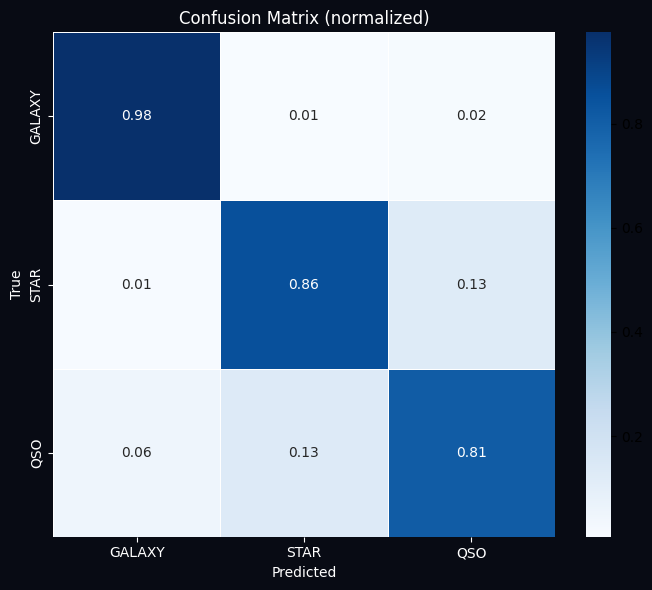

Saved: /content/drive/MyDrive/CelestialV2/results/confusion_matrix.png


In [ ]:
# D2 — Confusion matrix + classification report

# Load best model
ckpt = torch.load(CLASSIFIER, map_location=DEVICE)
clf.load_state_dict(ckpt['model_state_dict'])
clf.eval()
print(f'Loaded best model (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]*100:.2f}%)')

all_preds  = []
all_truths = []
with torch.no_grad():
    for imgs, labels in val_dl:
        out   = clf(imgs.to(DEVICE))
        preds = out.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_truths.extend(labels.tolist())

# Print report
print('\n=== Classification Report ===')
print(classification_report(all_truths, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm   = confusion_matrix(all_truths, all_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # normalize

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#080b14')
ax.set_facecolor('#0d1117')
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', color='white')
ax.set_ylabel('True',      color='white')
ax.set_title('Confusion Matrix (normalized)', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'confusion_matrix.png')
plt.savefig(p, dpi=130, bbox_inches='tight', facecolor='#080b14')
plt.show()
print('Saved:', p)

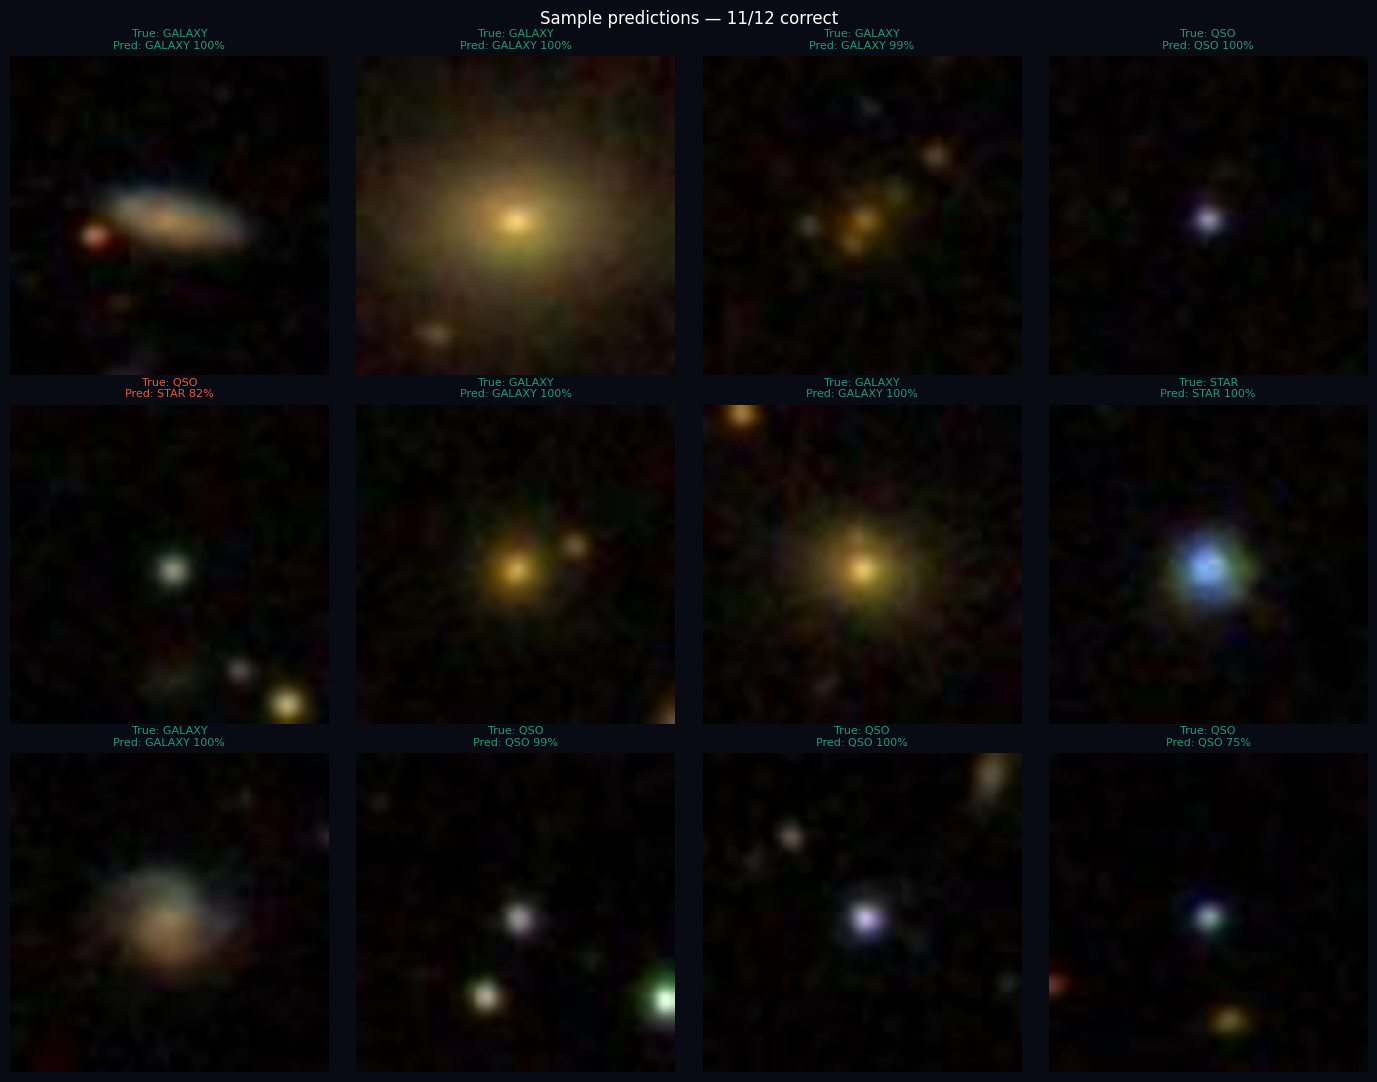

Saved: /content/drive/MyDrive/CelestialV2/results/classifier_samples.png


In [ ]:
# D3 — Visual sample predictions (3x4 grid)

sample_idx = random.sample(range(len(val_files)), 12)
fig, axes  = plt.subplots(3, 4, figsize=(14, 11))
fig.patch.set_facecolor('#080b14')
correct = 0

for ax, idx in zip(axes.flat, sample_idx):
    img_pil  = Image.open(val_files[idx]).convert('RGB')
    true_cls = CLASS_NAMES[val_labels[idx]]
    with torch.no_grad():
        t     = infer_tf(img_pil).unsqueeze(0).to(DEVICE)
        probs = torch.softmax(clf(t), dim=1)[0]
        pred  = CLASS_NAMES[probs.argmax().item()]
        conf  = float(probs.max())
    ok = pred == true_cls
    if ok: correct += 1
    ax.imshow(img_pil.resize((128,128)))
    ax.set_title(
        f'True: {true_cls}\nPred: {pred} {conf:.0%}',
        color='#1D9E75' if ok else '#E8593C', fontsize=8
    )
    ax.axis('off')

plt.suptitle(f'Sample predictions — {correct}/12 correct', color='white', fontsize=12)
plt.tight_layout()
p = os.path.join(RESULTS_DIR, 'classifier_samples.png')
plt.savefig(p, dpi=130, bbox_inches='tight', facecolor='#080b14')
plt.show()
print('Saved:', p)

---
# E — Build 3-Stage Detection Pipeline

**Stage 1 — photutils DAOStarFinder** → finds every bright source in the image
**Stage 2 — ResNet50** → classifies each source: GALAXY / STAR / QSO
**Stage 3 — YOLOv8** → catches extended objects (nebulae, clusters) in parallel

In [ ]:
# E1 — Load YOLO
yolo = YOLO(YOLO_DST) if os.path.exists(YOLO_DST) else None
print('YOLO:', 'loaded' if yolo else 'NOT FOUND — pipeline runs without it')

YOLO: loaded


In [ ]:
# E2 — Pipeline functions

CLASS_COLORS = {
    'STAR':   (59,  139, 212),   # blue
    'GALAXY': (229, 89,  52),    # orange-red
    'QSO':    (29,  158, 117),   # teal
}

def classify_crop(crop_pil):
    """ResNet50: crop → (class_name, confidence)"""
    clf.eval()
    with torch.no_grad():
        t     = infer_tf(crop_pil.convert('RGB')).unsqueeze(0).to(DEVICE)
        probs = torch.softmax(clf(t), dim=1)[0]
    return CLASS_NAMES[probs.argmax().item()], float(probs.max())


def detect_pipeline(img_pil, conf_thresh=0.25, phot_sigma=4.0,
                    phot_fwhm=3.0, crop_size=32, max_sources=400):
    """
    Full 3-stage pipeline.
    Returns list of dicts: x1,y1,x2,y2, class_name, confidence, source
    """
    img_np  = np.array(img_pil)
    W, H    = img_pil.size
    results = []

    # Stage 1 — photutils: find all point sources
    gray           = np.mean(img_np, axis=2).astype(np.float64)
    _, median, std = sigma_clipped_stats(gray, sigma=3.0)
    finder         = DAOStarFinder(fwhm=phot_fwhm, threshold=phot_sigma * std)
    sources        = finder(gray - median)

    if sources is not None:
        src_list = sorted(
            [(float(s['xcentroid']), float(s['ycentroid']), float(s['flux']))
             for s in sources],
            key=lambda x: -x[2]
        )[:max_sources]

        # Stage 2 — classify each source
        half = crop_size // 2
        for (x, y, flux) in src_list:
            xi, yi = int(x), int(y)
            x1 = max(0, xi - half);  x2 = min(W, xi + half)
            y1 = max(0, yi - half);  y2 = min(H, yi + half)
            if x2 - x1 < 8 or y2 - y1 < 8:
                continue
            cls_name, cls_conf = classify_crop(img_pil.crop((x1, y1, x2, y2)))
            results.append({
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'class_name': cls_name,
                'confidence': round(cls_conf, 4),
                'source': 'photutils'
            })

    # Stage 3 — YOLO: catch extended objects
    if yolo is not None:
        yr = yolo.predict(
            source=img_np, conf=conf_thresh,
            iou=0.45, imgsz=640, verbose=False
        )[0]
        if yr.boxes is not None:
            for box in yr.boxes:
                bx1,by1,bx2,by2 = [int(v) for v in box.xyxy[0].tolist()]
                if bx2 - bx1 < 20 or by2 - by1 < 20:
                    continue
                cls_name, cls_conf = classify_crop(img_pil.crop((bx1,by1,bx2,by2)))
                results.append({
                    'x1': bx1, 'y1': by1, 'x2': bx2, 'y2': by2,
                    'class_name': cls_name,
                    'confidence': round(max(float(box.conf[0]), cls_conf), 4),
                    'source': 'yolo'
                })

    return results


def draw_detections(img_pil, detections):
    """Draw boxes/dots on image and return annotated PIL image."""
    from PIL import ImageDraw, ImageFont
    out  = img_pil.copy()
    draw = ImageDraw.Draw(out, 'RGBA')
    try:
        font = ImageFont.truetype(
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 11
        )
    except Exception:
        font = ImageFont.load_default()

    for d in detections:
        col  = CLASS_COLORS.get(d['class_name'], (180, 180, 180))
        x1,y1,x2,y2 = d['x1'], d['y1'], d['x2'], d['y2']
        conf = d['confidence']

        if d['class_name'] == 'STAR':
            # Stars → small circle (avoids label clutter)
            cx, cy = (x1+x2)//2, (y1+y2)//2
            draw.ellipse([cx-3, cy-3, cx+3, cy+3], outline=col, width=1)
        else:
            # Galaxies / QSOs → box + label
            for t in range(2):
                draw.rectangle([x1-t,y1-t,x2+t,y2+t], outline=col)
            lbl = f'{d["class_name"]} {conf:.0%}'
            tw  = len(lbl) * 7
            draw.rectangle([x1, y1-18, x1+tw, y1], fill=(0,0,0,180))
            draw.text((x1+2, y1-16), lbl, fill=(255,255,255), font=font)

    return out


print('Pipeline ready.')
print('Functions: detect_pipeline(), draw_detections()')

Pipeline ready.
Functions: detect_pipeline(), draw_detections()


---
# F — Test Pipeline on Your Telescope Image

**How to use:**
1. Upload your telescope image using the Colab file sidebar (📁 icon on the left)
2. Set `MY_IMAGE` to the filename you uploaded
3. Run the cell

Image: 4666.jpg  (608×608px)
Running 3-stage detection...

=== Results (5109ms) ===
Total objects detected: 501
  GALAXY      25  █████
  STAR       475  ███████████████████████████████████████████████████████████████████████████████████████████████
  QSO          1  


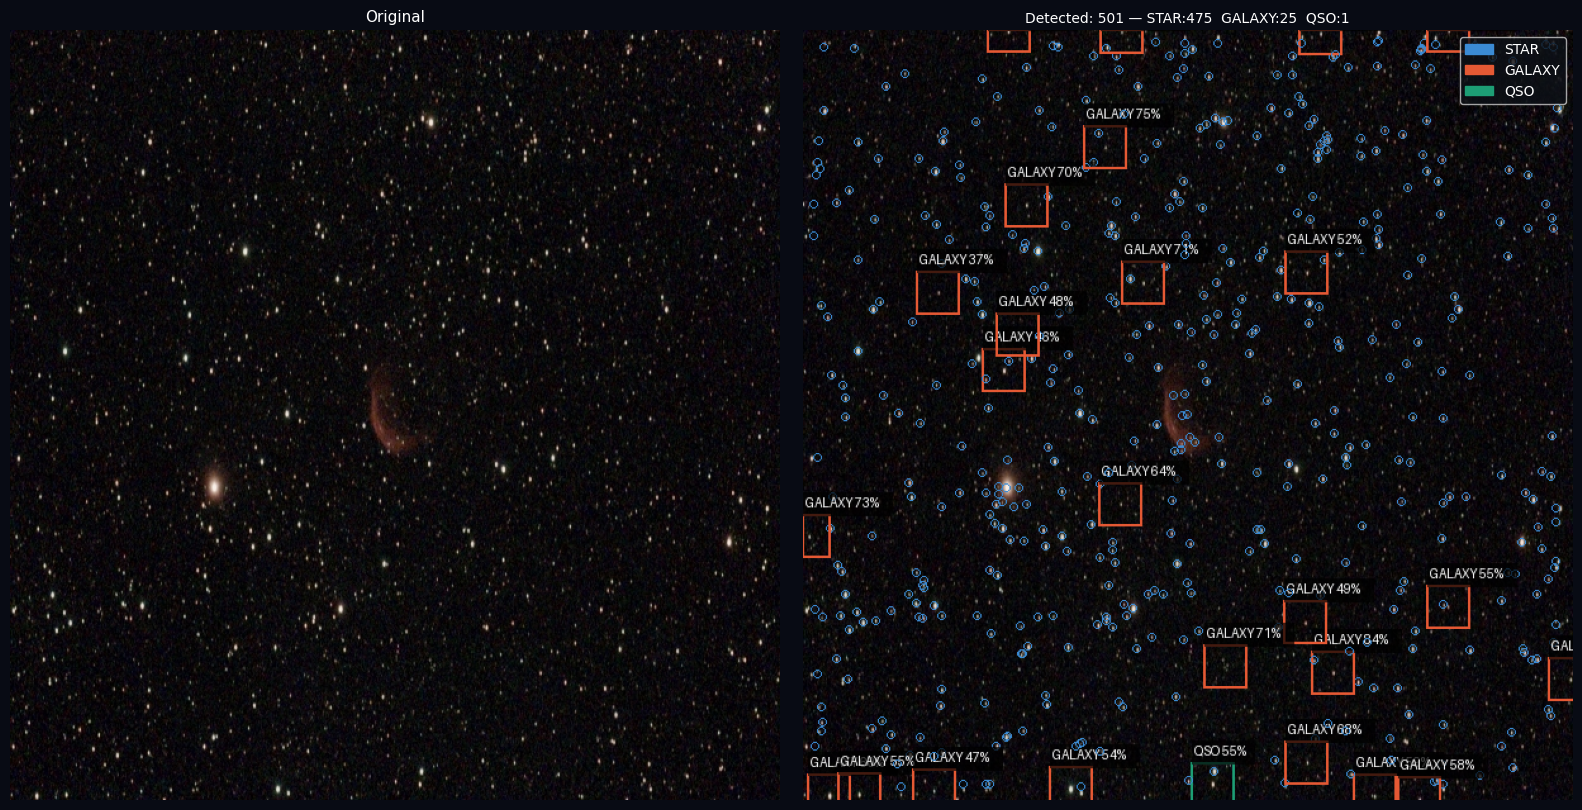

Saved: /content/drive/MyDrive/CelestialV2/results/pipeline_result.png


In [ ]:
# F1 — Test on your uploaded image
# ─────────────────────────────────────────────────────────────
# HOW TO USE:
#   1. Click the Files icon (📁) in the left sidebar
#   2. Click Upload and select your telescope image
#   3. Change the filename below to match what you uploaded
# ─────────────────────────────────────────────────────────────
MY_IMAGE = '/content/4666.jpg'   # ← CHANGE THIS to your image filename
# ─────────────────────────────────────────────────────────────

if not os.path.exists(MY_IMAGE):
    print(f'Image not found at: {MY_IMAGE}')
    print('Upload your image and update MY_IMAGE above.')
else:
    img_pil = Image.open(MY_IMAGE).convert('RGB')
    print(f'Image: {Path(MY_IMAGE).name}  ({img_pil.width}×{img_pil.height}px)')

    print('Running 3-stage detection...')
    t0   = time.time()
    dets = detect_pipeline(
        img_pil,
        conf_thresh  = 0.25,
        phot_sigma   = 4.0,    # lower = more detections (try 3.0 for faint stars)
        phot_fwhm    = 3.0,
        max_sources  = 500,
    )
    ms = (time.time()-t0)*1000

    counts = Counter(d['class_name'] for d in dets)
    print(f'\n=== Results ({ms:.0f}ms) ===')
    print(f'Total objects detected: {len(dets)}')
    for cls in CLASS_NAMES:
        n = counts.get(cls, 0)
        bar = '█' * (n // 5)
        print(f'  {cls:<8s}  {n:4d}  {bar}')

    annotated = draw_detections(img_pil, dets)

    # Show side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('#080b14')
    axes[0].imshow(img_pil)
    axes[0].set_title('Original', color='white', fontsize=11)
    axes[0].axis('off')
    axes[1].imshow(annotated)
    axes[1].set_title(
        f'Detected: {len(dets)} — ' +
        '  '.join(f'{k}:{v}' for k,v in counts.items()),
        color='white', fontsize=10
    )
    axes[1].axis('off')

    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(color=tuple(c/255 for c in v), label=k)
              for k,v in CLASS_COLORS.items()]
    axes[1].legend(handles=legend, loc='upper right',
                   facecolor='#0d1117', labelcolor='white')

    plt.tight_layout()
    out_path = os.path.join(RESULTS_DIR, 'pipeline_result.png')
    plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#080b14')
    plt.show()
    print(f'Saved: {out_path}')

---
# G — Save All Files to Drive

In [ ]:
# G1 — Write classes.txt
with open(CLASSES_TXT, 'w') as f:
    f.write('\n'.join(CLASS_NAMES))
print('classes.txt saved.')

# G2 — Final summary
print('\n=== All files saved to Drive ===')
files = [
    (CLASSIFIER,                                     'ResNet50 classifier weights'),
    (YOLO_DST,                                       'YOLOv8 detection model'),
    (CLASSES_TXT,                                    'Class names file'),
    (os.path.join(RESULTS_DIR,'training_curves.png'),'Training curves'),
    (os.path.join(RESULTS_DIR,'confusion_matrix.png'),'Confusion matrix'),
    (os.path.join(RESULTS_DIR,'classifier_samples.png'),'Sample predictions'),
    (os.path.join(RESULTS_DIR,'pipeline_result.png'), 'Pipeline result image'),
]
for path, desc in files:
    if os.path.exists(path):
        size = os.path.getsize(path)/1e6
        print(f'  ✅  {desc:<35s}  {size:.1f} MB')
    else:
        print(f'  ⚠️   {desc:<35s}  not found')

print()
print('══════════════════════════════════════')
print('NEXT STEPS — local VS Code setup:')
print('══════════════════════════════════════')
print(f'1. Download from Drive/CelestialV2/:')
print(f'     resnet50_classifier.pt  → put in CelestialV2/model/')
print(f'     yolo_best.pt            → put in CelestialV2/model/')
print(f'     classes.txt             → put in CelestialV2/model/')
print(f'2. Open CelestialV2/ in VS Code')
print(f'3. cd backend && pip install -r requirements.txt')
print(f'4. uvicorn main:app --reload --port 8000')
print(f'5. cd frontend && pip install -r requirements.txt')
print(f'6. streamlit run app.py')

classes.txt saved.

=== All files saved to Drive ===
  ✅  ResNet50 classifier weights          98.6 MB
  ✅  YOLOv8 detection model               18.5 MB
  ✅  Class names file                     0.0 MB
  ✅  Training curves                      0.1 MB
  ✅  Confusion matrix                     0.0 MB
  ✅  Sample predictions                   0.3 MB
  ✅  Pipeline result image                2.1 MB

══════════════════════════════════════
NEXT STEPS — local VS Code setup:
══════════════════════════════════════
1. Download from Drive/CelestialV2/:
     resnet50_classifier.pt  → put in CelestialV2/model/
     yolo_best.pt            → put in CelestialV2/model/
     classes.txt             → put in CelestialV2/model/
2. Open CelestialV2/ in VS Code
3. cd backend && pip install -r requirements.txt
4. uvicorn main:app --reload --port 8000
5. cd frontend && pip install -r requirements.txt
6. streamlit run app.py
